# Tutorial 21 -- Building Sequences from Gates and Pulses

Combine public pulse builders with `SequenceCompiler` to create a short multi-channel schedule and inspect the resulting sampled control waveforms.

**Prerequisites.** Tutorials 03, 04, and 09 are recommended first.


## 1. Goal

We will build a displacement followed by two qubit rotations, compile the schedule onto a common time grid, and inspect the resulting channel data.


## 2. Physical Background

The public gate classes (`DisplacementGate`, `RotationGate`, and friends) are small API objects. The pulse builders turn them into control waveforms, and `SequenceCompiler` places everything onto one global timeline.


## 3. Imports


In [1]:
from __future__ import annotations

from functools import partial
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from cqed_sim import (
    AmplifierChain,
    BosonicModeSpec,
    DispersiveCouplingSpec,
    DispersiveReadoutTransmonStorageModel,
    DispersiveTransmonCavityModel,
    DisplacementGate,
    FrameSpec,
    NoiseSpec,
    Pulse,
    PurcellFilter,
    QubitMeasurementSpec,
    ReadoutChain,
    ReadoutResonator,
    RotationGate,
    SidebandDriveSpec,
    SequenceCompiler,
    SimulationConfig,
    StatePreparationSpec,
    TransmonModeSpec,
    UniversalCQEDModel,
    build_displacement_pulse,
    build_rotation_pulse,
    build_sideband_pulse,
    carrier_for_transition_frequency,
    coherent_state,
    compute_energy_spectrum,
    fock_state,
    manifold_transition_frequency,
    measure_qubit,
    prepare_simulation,
    prepare_state,
    pure_dephasing_time_from_t1_t2,
    qubit_state,
    run_rabi,
    run_ramsey,
    run_spectroscopy,
    run_t1,
    run_t2_echo,
    sideband_transition_frequency,
    simulate_batch,
    simulate_sequence,
)
from cqed_sim.plotting import plot_energy_levels
from cqed_sim.pulses import gaussian_envelope, square_envelope
from cqed_sim.sim import (
    cavity_wigner,
    conditioned_bloch_xyz,
    mode_moments,
    qubit_conditioned_mode_moments,
    readout_response_by_qubit_state,
    reduced_cavity_state,
    reduced_qubit_state,
    reduced_storage_state,
    storage_photon_number,
    subsystem_level_population,
    transmon_level_populations,
)
from tutorials.tutorial_support import (
    GHz,
    MHz,
    angular_to_ghz,
    angular_to_hz,
    angular_to_mhz,
    cross_kerr_conditional_phase,
    final_expectation,
    fit_echo_signal,
    fit_exponential_decay,
    fit_lorentzian_peak,
    fit_rabi_vs_amplitude,
    fit_rabi_vs_duration,
    fit_ramsey_signal,
    gaussian_quasistatic_echo_excited_population,
    gaussian_quasistatic_ramsey_excited_population,
    ns,
    ramsey_population,
    resonant_drive_excited_population,
    t1_relaxation_population,
    us,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7.0, 4.2)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 4. Simulation Parameters


In [2]:
displacement_duration = 120.0 * ns
rotation_duration = 40.0 * ns
dt = 2.0 * ns


## 5. Model Construction


In [3]:
model = DispersiveTransmonCavityModel(
    omega_c=GHz(5.0),
    omega_q=GHz(6.2),
    alpha=0.0,
    chi=0.0,
    kerr=0.0,
    n_cav=10,
    n_tr=2,
)
frame = FrameSpec(omega_c_frame=model.omega_c, omega_q_frame=model.omega_q)


## 6. Pulse / Sequence Construction


In [4]:
disp_pulses, disp_drive_ops, _ = build_displacement_pulse(
    DisplacementGate(index=0, name="D(alpha)", re=0.8, im=0.0),
    {"duration_displacement_s": displacement_duration},
)
x90_pulses, x90_drive_ops, _ = build_rotation_pulse(
    RotationGate(index=1, name="x90", theta=np.pi / 2.0, phi=0.0),
    {"duration_rotation_s": rotation_duration, "rotation_sigma_fraction": 0.18},
)
y90_pulses, _, _ = build_rotation_pulse(
    RotationGate(index=2, name="y90", theta=np.pi / 2.0, phi=np.pi / 2.0),
    {"duration_rotation_s": rotation_duration, "rotation_sigma_fraction": 0.18},
)
x90 = x90_pulses[0]
y90 = y90_pulses[0]
pulse_sequence = [
    disp_pulses[0],
    Pulse(x90.channel, displacement_duration + 10.0 * ns, x90.duration, x90.envelope, amp=x90.amp, carrier=x90.carrier, phase=x90.phase, label=x90.label),
    Pulse(y90.channel, displacement_duration + rotation_duration + 20.0 * ns, y90.duration, y90.envelope, amp=y90.amp, carrier=y90.carrier, phase=y90.phase, label=y90.label),
]
drive_ops = {"storage": "cavity", "qubit": "qubit"}
t_end = displacement_duration + 2.0 * rotation_duration + 30.0 * ns
compiled = SequenceCompiler(dt=dt).compile(pulse_sequence, t_end=t_end)


## 7. Running the Simulation


In [5]:
result = simulate_sequence(
    model,
    compiled,
    model.basis_state(0, 0),
    drive_ops,
    config=SimulationConfig(frame=frame, max_step=dt),
)
print(f"Final qubit excitation = {final_expectation(result, 'P_e'):.4f}")
print(f"Final cavity photon number = {mode_moments(result.final_state, 'storage')['n']:.4f}")


Final qubit excitation = 0.5000
Final cavity photon number = 0.6294


## 8. Visualizing the Results


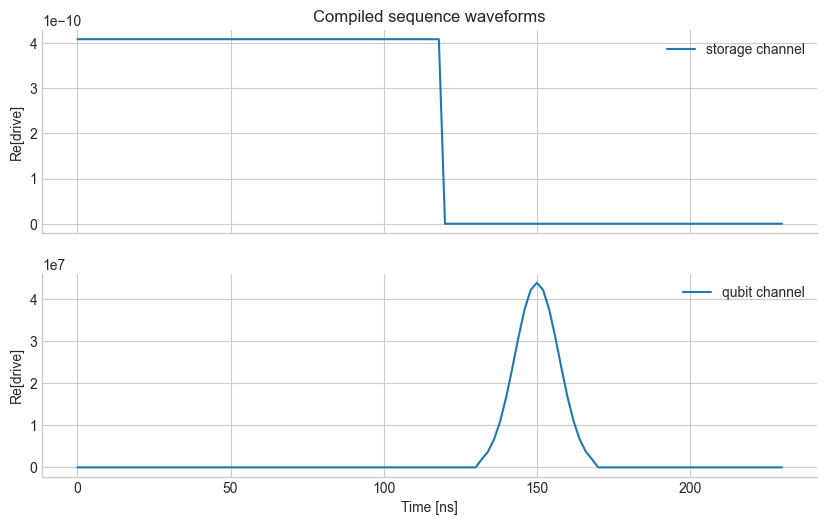

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10.0, 5.8), sharex=True)
axes[0].plot(compiled.tlist / ns, np.real(compiled.channels["storage"].distorted), label="storage channel")
axes[0].set_ylabel("Re[drive]")
axes[0].legend()
axes[0].set_title("Compiled sequence waveforms")

axes[1].plot(compiled.tlist / ns, np.real(compiled.channels["qubit"].distorted), label="qubit channel")
axes[1].set_xlabel("Time [ns]")
axes[1].set_ylabel("Re[drive]")
axes[1].legend()
plt.show()


## 9. Physical Interpretation

The gate objects are just the front door. The actual solver sees sampled complex envelopes on named channels, and the compiler is the layer that makes multi-channel timing explicit.


## 10. Exercises / Next Steps

- Insert an explicit idle gap and compare the compiled waveforms.
- Replace the manual pulse shifts with your own small scheduling helper if you need a repeated pattern.
- Continue to Tutorial 22 to see how prepared sessions help with repeated execution.
